<a href="https://colab.research.google.com/github/Gabriel-idkw/Customer-Behavior-Prediction/blob/main/02_kmeans_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 — K-Means Clustering
### Grid Search, Tuning, Metrics, Visualization

Loads the shared baseline from Notebook 01 (`data/preprocessed_rfm_scaled.csv`) and runs a full grid search over K-Means hyperparameters, independent of Notebooks 03/04. Exports `models/kmeans_model.pkl` and `metrics/kmeans_results.json` for Notebook 05 to compare.

In [12]:
from google.colab import drive
drive.mount('/content/drive')

import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score, calinski_harabasz_score

sns.set_style('whitegrid')
RANDOM_STATE = 42
PROJECT_ROOT = '/content/drive/MyDrive/customer-segmentation-ml'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Load the shared baseline

In [13]:
X_df = pd.read_csv(f'{PROJECT_ROOT}/data/preprocessed_rfm_scaled.csv')
customer_ids = X_df['Customer ID']
X = X_df.drop(columns=['Customer ID']).values
feature_names = X_df.drop(columns=['Customer ID']).columns.tolist()

raw_df = pd.read_csv(f'{PROJECT_ROOT}/data/customer_features_raw.csv')  # for interpreting clusters later

print('X shape:', X.shape)


X shape: (49661, 16)


## 2. Grid search

Sweep:
- **K**: 2–8
- **init**: `k-means++` vs `random`
- **n_init**: 10, 20, 30

For each combination we record Silhouette, Davies-Bouldin, and Calinski-Harabasz. Silhouette Score is `O(n²)` — with ~49,661 customers a full computation per grid point is too slow to repeat 42 times, so we estimate it on a **fixed random sample of 5,000 customers** (`sample_size=5000`) for the grid search; Davies-Bouldin and Calinski-Harabasz are computed on the **full** dataset since sklearn computes those from cluster centroids/dispersion, which is cheap.

In [14]:
K_range = range(2, 9)
init_options = ['k-means++', 'random']
n_init_options = [10, 20, 30]
SIL_SAMPLE_SIZE = 5000

grid_results = []
for k in K_range:
    for init in init_options:
        for n_init in n_init_options:
            km = KMeans(n_clusters=k, init=init, n_init=n_init, random_state=RANDOM_STATE)
            labels = km.fit_predict(X)

            sil = silhouette_score(X, labels, sample_size=SIL_SAMPLE_SIZE, random_state=RANDOM_STATE)
            db = davies_bouldin_score(X, labels)
            ch = calinski_harabasz_score(X, labels)

            grid_results.append({
                'k': k, 'init': init, 'n_init': n_init,
                'inertia': float(km.inertia_),
                'silhouette': float(sil),
                'davies_bouldin': float(db),
                'calinski_harabasz': float(ch),
            })

results_df = pd.DataFrame(grid_results)
results_df.sort_values('silhouette', ascending=False).head(10)


,k,init,n_init,inertia,silhouette,davies_bouldin,calinski_harabasz
3,2,random,10,369208.199130,0.200833,2.131280,9613.417786
4,2,random,20,369208.097963,0.200686,2.131788,9613.423769
5,2,random,30,369208.097963,0.200686,2.131788,9613.423769
0,2,k-means++,10,369208.495807,0.200397,2.133672,9613.369380
1,2,k-means++,20,369208.384247,0.200343,2.133256,9613.385595
2,2,k-means++,30,369208.384247,0.200343,2.133256,9613.385595
23,5,random,30,303807.468763,0.104082,2.233480,5592.910826
20,5,k-means++,30,303807.673981,0.104071,2.233441,5592.901566
19,5,k-means++,20,303807.684749,0.104071,2.233502,5592.901241
18,5,k-means++,10,303807.684749,0.104071,2.233502,5592.901241


## 3. Elbow curve

Inertia (WCSS) vs K, using the `k-means++` / `n_init=10` slice of the grid — the classic "bend point" plot.

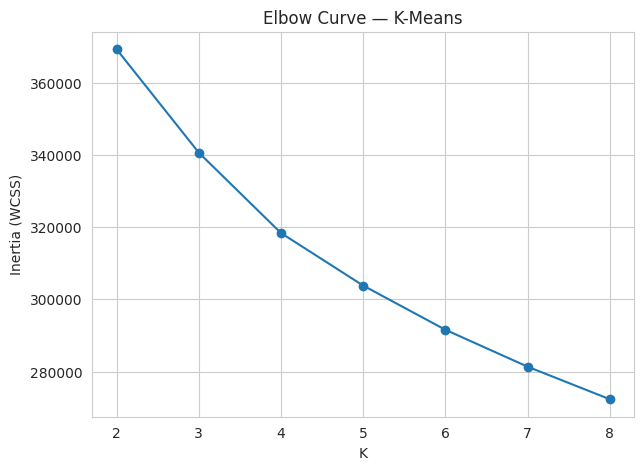

In [15]:
elbow_slice = results_df[(results_df['init'] == 'k-means++') & (results_df['n_init'] == 10)].sort_values('k')

plt.figure(figsize=(7, 5))
plt.plot(elbow_slice['k'], elbow_slice['inertia'], marker='o')
plt.xlabel('K')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Curve — K-Means')
plt.xticks(list(K_range))
plt.show()


## 4. Silhouette score vs K

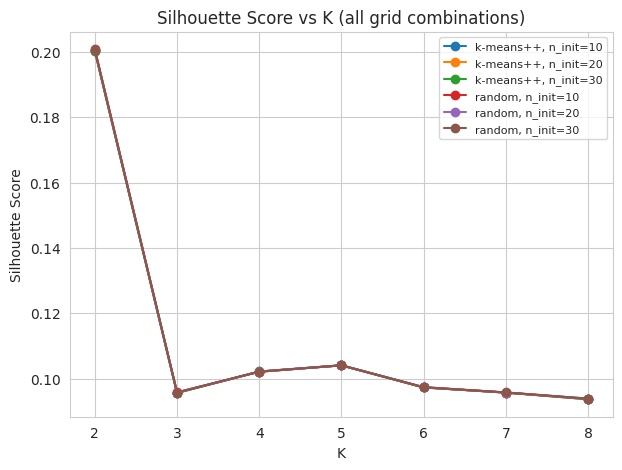

In [16]:
plt.figure(figsize=(7, 5))
for init in init_options:
    for n_init in n_init_options:
        sl = results_df[(results_df['init'] == init) & (results_df['n_init'] == n_init)].sort_values('k')
        plt.plot(sl['k'], sl['silhouette'], marker='o', label=f'{init}, n_init={n_init}')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs K (all grid combinations)')
plt.legend(fontsize=8)
plt.xticks(list(K_range))
plt.show()


## 5. Pick the best configuration and refit

In [17]:
best_row = results_df.sort_values('silhouette', ascending=False).iloc[0]
BEST_K = int(best_row['k'])
BEST_INIT = best_row['init']
BEST_N_INIT = int(best_row['n_init'])

print('Best config by silhouette:')
print(best_row)

final_kmeans = KMeans(n_clusters=BEST_K, init=BEST_INIT, n_init=BEST_N_INIT, random_state=RANDOM_STATE)
final_labels = final_kmeans.fit_predict(X)


Best config by silhouette:
k                               2
init                       random
n_init                         10
inertia              369208.19913
silhouette               0.200833
davies_bouldin            2.13128
calinski_harabasz     9613.417786
Name: 3, dtype: object


## 6. Silhouette profile plot

Per-sample silhouette width by cluster, for the chosen K — verifies cluster balance (uniformly wide bars near 1 = well-separated; thin or negative bars = weak assignment). Computed on a 5,000-point sample for the same `O(n²)` reason as above.

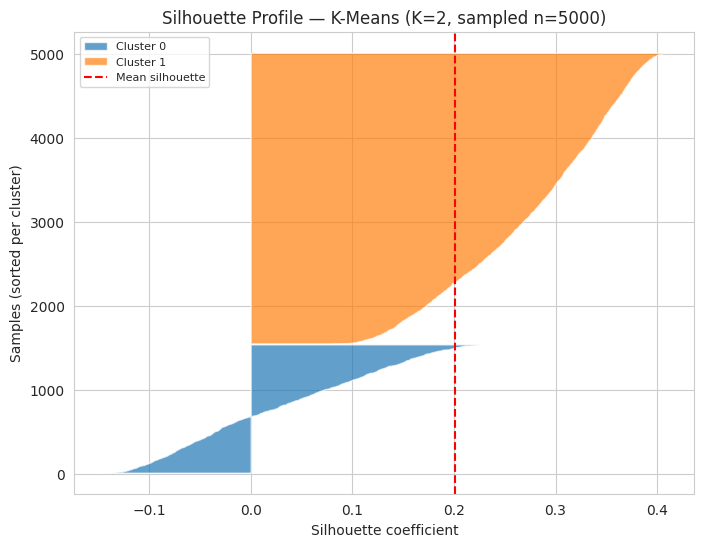

In [18]:
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(len(X), size=SIL_SAMPLE_SIZE, replace=False)
X_sample, labels_sample = X[sample_idx], final_labels[sample_idx]
sample_silhouette_values = silhouette_samples(X_sample, labels_sample)

fig, ax = plt.subplots(figsize=(8, 6))
y_lower = 10
for i in range(BEST_K):
    ith_values = np.sort(sample_silhouette_values[labels_sample == i])
    size_i = ith_values.shape[0]
    y_upper = y_lower + size_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_values, alpha=0.7, label=f'Cluster {i}')
    y_lower = y_upper + 10

ax.axvline(x=sample_silhouette_values.mean(), color='red', linestyle='--', label='Mean silhouette')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Samples (sorted per cluster)')
ax.set_title(f'Silhouette Profile — K-Means (K={BEST_K}, sampled n={SIL_SAMPLE_SIZE})')
ax.legend(fontsize=8)
plt.show()


## 7. 2D PCA scatter of clusters

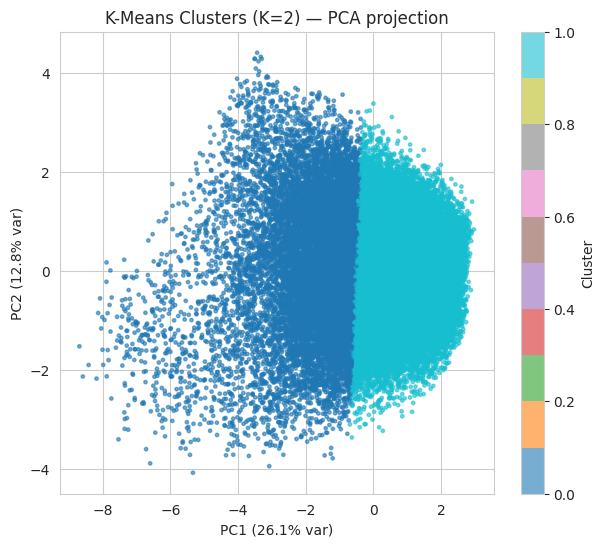

In [19]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=final_labels, cmap='tab10', s=6, alpha=0.6)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
plt.title(f'K-Means Clusters (K={BEST_K}) — PCA projection')
plt.colorbar(scatter, label='Cluster')
plt.show()


## 8. Cluster profile (sanity check in real units)

Average `recency_days`, `frequency`, `monetary_total` per cluster, using the **unscaled** raw feature table — this is what makes the segments interpretable, and lets us sanity-check against `churn` (not used for training).

In [20]:
profile_df = raw_df.copy()
profile_df['cluster'] = final_labels

display_cols = ['recency_days', 'frequency', 'monetary_total', 'monetary_avg', 'return_rate', 'churn']
cluster_profile = profile_df.groupby('cluster')[display_cols].mean().round(2)
cluster_profile['n_customers'] = profile_df.groupby('cluster').size()
cluster_profile


,recency_days,frequency,monetary_total,monetary_avg,return_rate,churn,n_customers
cluster,,,,,,,
0,456.45,2.86,6608.46,2422.58,40.47,0.2,14963
1,178.63,5.95,16724.80,2858.50,40.67,0.2,34698


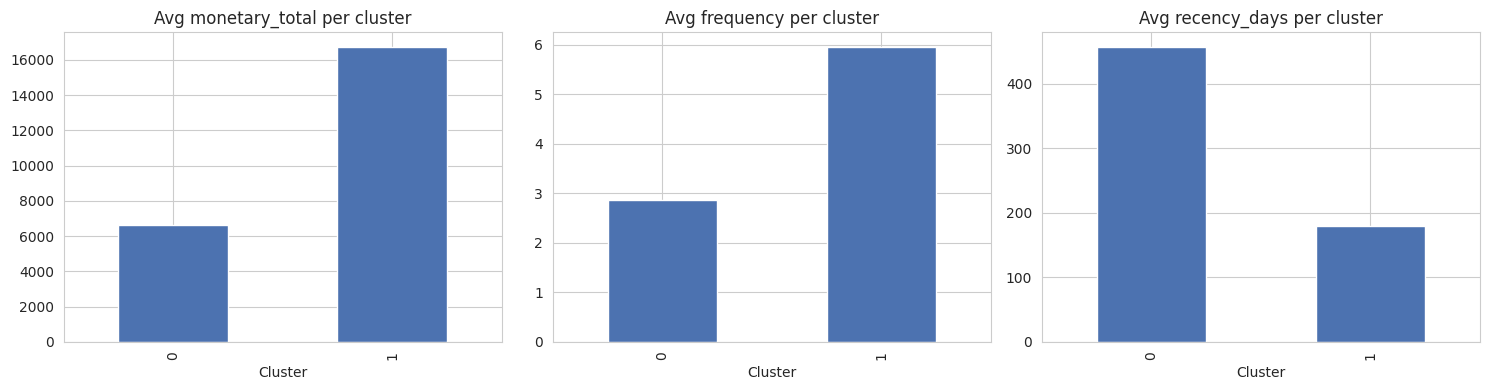

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['monetary_total', 'frequency', 'recency_days']):
    cluster_profile[col].plot(kind='bar', ax=ax, color='#4C72B0')
    ax.set_title(f'Avg {col} per cluster')
    ax.set_xlabel('Cluster')
plt.tight_layout()
plt.show()


## 9. Export

In [22]:
joblib.dump(final_kmeans, f'{PROJECT_ROOT}/models/kmeans_model.pkl')

kmeans_results = {
    'algorithm': 'KMeans',
    'grid_search': grid_results,
    'best_params': {'k': BEST_K, 'init': BEST_INIT, 'n_init': BEST_N_INIT},
    'best_metrics': {
        'silhouette': float(best_row['silhouette']),
        'davies_bouldin': float(best_row['davies_bouldin']),
        'calinski_harabasz': float(best_row['calinski_harabasz']),
    },
    'n_clusters_found': BEST_K,
    'notes': "Supports native .predict() on new data - this is the model deployed in the Gradio app.",
}
with open(f'{PROJECT_ROOT}/metrics/kmeans_results.json', 'w') as f:
    json.dump(kmeans_results, f, indent=2)

print('Saved models/kmeans_model.pkl and metrics/kmeans_results.json')
print(json.dumps(kmeans_results['best_params'], indent=2))
print(json.dumps(kmeans_results['best_metrics'], indent=2))


Saved models/kmeans_model.pkl and metrics/kmeans_results.json
{
  "k": 2,
  "init": "random",
  "n_init": 10
}
{
  "silhouette": 0.20083343542449608,
  "davies_bouldin": 2.131279993910449,
  "calinski_harabasz": 9613.417785995594
}
